# Launch Modeling Weather V2: Base Model Vs Weather-Enhanced Subset

This notebook tests a different strategy for weather features:

- keep a base launch-history model for the full sample
- define a stricter **good-weather-coverage subset**
- compare a base model and a weather-enhanced model on that same subset

The idea is to stop forcing sparse weather variables into every row and instead ask whether weather helps when the matching quality is actually good.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data/derived")
RANDOM_STATE = 42


In [16]:
df = pd.read_csv(DATA_DIR / "us_launch_weather_merged.csv", low_memory=False)
df["launch_date"] = pd.to_datetime(df["launch_date"], errors="coerce")
df = df.sort_values(["launch_date", "Launch Id"]).reset_index(drop=True)

df["launch_month"] = df["launch_date"].dt.month
df["launch_year_centered"] = df["launch_year"] - df["launch_year"].median()
df["mission_mass_log"] = np.log1p(df["mission_mass"].clip(lower=0))
df["rocket_payload_leo_log"] = np.log1p(df["rocket_payload_leo"].clip(lower=0))
df["config_liftoff_thrust_log"] = np.log1p(df["config_liftoff_thrust"].clip(lower=0))
df["dewpoint_depression"] = df["HourlyDryBulbTemperature"] - df["HourlyDewPointTemperature"]
df["visibility_log"] = np.log1p(df["HourlyVisibility"].clip(lower=0))
df["wind_x_visibility"] = df["HourlyWindSpeed"] * df["HourlyVisibility"]

print("Rows:", len(df))
display(
    df["launch_failure_binary"]
    .value_counts()
    .rename(index={0: "Success", 1: "Not Success"})
    .to_frame("count")
)


Rows: 1784


,count
launch_failure_binary,
Success,1597
Not Success,187


#### What this shows

The notebook starts from the same full merged modeling table as the other workflows. Its purpose is narrower: to test whether weather variables become more useful when they are only applied to launches with stronger weather coverage and closer launch-to-observation timing.


## 1. Define The Weather-Quality Subset

The subset is intentionally stricter than the original full sample. A launch is included if:

- weather was matched
- the weather observation is close enough to launch time
- the key weather variables needed for the weather-enhanced model are present


In [17]:
weather_subset = df[
    (df["weather_matched"] == True)
    & (df["weather_time_diff_minutes"] <= 30)
    & df["HourlyWindSpeed"].notna()
    & df["HourlyVisibility"].notna()
    & df["HourlyAltimeterSetting"].notna()
    & df["HourlyWetBulbTemperature"].notna()
].copy()

subset_summary = pd.DataFrame(
    [
        {
            "sample": "full sample",
            "rows": len(df),
            "failure_rate": df["launch_failure_binary"].mean(),
            "start_date": df["launch_date"].min().date(),
            "end_date": df["launch_date"].max().date(),
        },
        {
            "sample": "good weather subset",
            "rows": len(weather_subset),
            "failure_rate": weather_subset["launch_failure_binary"].mean(),
            "start_date": weather_subset["launch_date"].min().date(),
            "end_date": weather_subset["launch_date"].max().date(),
        },
    ]
)
subset_summary


,sample,rows,failure_rate,start_date,end_date
0,full sample,1784,0.104821,1957-12-06,2021-12-21
1,good weather subset,243,0.057613,1973-03-06,2021-12-21


#### What this section is doing

This step defines a stricter ?good weather? subset. A launch is only kept if the weather match is close in time and the key weather variables needed for the weather-enhanced model are present.

#### How to interpret the output

The main tradeoff is visible immediately: the subset is cleaner from a weather-data standpoint, but it is also much smaller and lower-risk than the full dataset. That means any later performance gains are on a narrower and potentially easier sample.


In [18]:
coverage_by_facility = (
    df.assign(in_weather_subset=df.index.isin(weather_subset.index))
    .groupby("facility_group", dropna=False)
    .agg(
        launches=("Launch Id", "count"),
        subset_launches=("in_weather_subset", "sum"),
        subset_share=("in_weather_subset", "mean"),
    )
    .reset_index()
    .sort_values("launches", ascending=False)
)

coverage_by_facility


,facility_group,launches,subset_launches,subset_share
0,Cape Canaveral Space Force Station,810,115,0.141975
7,Vandenberg Space Force Base,711,63,0.088608
3,Kennedy Space Center,192,36,0.187500
8,Wallops Flight Facility,49,23,0.469388
6,Pacific Spaceport Complex Alaska,7,3,0.428571
1,China Lake,6,0,0.000000
2,Edwards Air Force Base,5,0,0.000000
4,Mojave Air and Space Port,3,2,0.666667
5,Pacific Missile Range Facility,1,1,1.000000


#### What these coverage diagnostics mean

These outputs show whether the weather subset still looks representative. The answer is mixed. Some facilities retain a reasonable share of launches, but others contribute very little or nothing. That makes this notebook better suited to testing subset feasibility than to establishing a final production workflow.


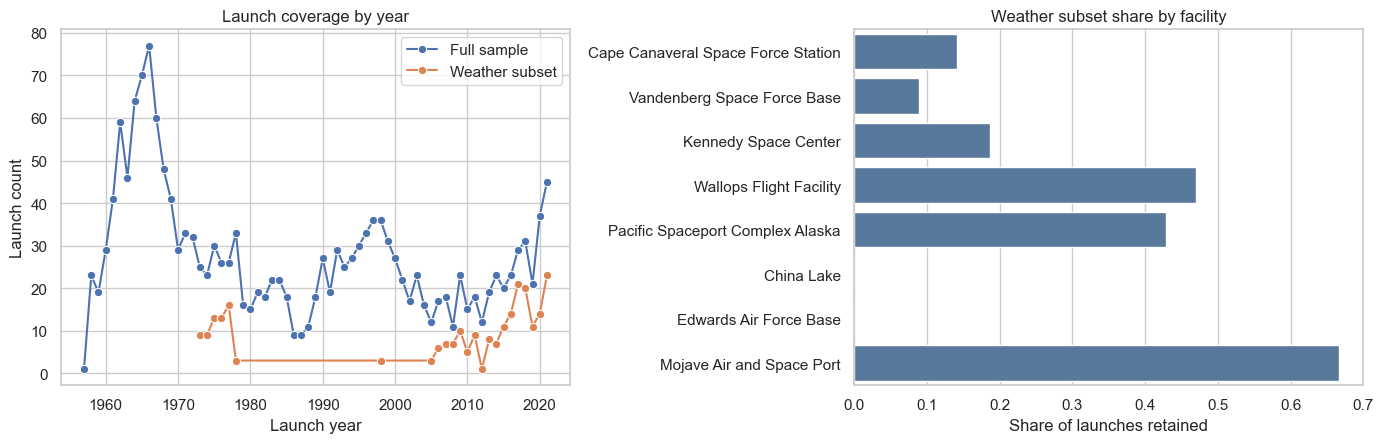

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

full_year = df.groupby("launch_year").size().reset_index(name="launches")
subset_year = weather_subset.groupby("launch_year").size().reset_index(name="launches")

sns.lineplot(data=full_year, x="launch_year", y="launches", marker="o", ax=axes[0], label="Full sample")
sns.lineplot(data=subset_year, x="launch_year", y="launches", marker="o", ax=axes[0], label="Weather subset")
axes[0].set_title("Launch coverage by year")
axes[0].set_xlabel("Launch year")
axes[0].set_ylabel("Launch count")

sns.barplot(data=coverage_by_facility.head(8), y="facility_group", x="subset_share", ax=axes[1], color="#4e79a7")
axes[1].set_title("Weather subset share by facility")
axes[1].set_xlabel("Share of launches retained")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


These checks matter because the weather-subset strategy only makes sense if the retained sample is still large enough and not dominated by a single site or era.


In [20]:
def chronological_split(frame):
    temp = frame.dropna(subset=["launch_date"]).sort_values(["launch_date", "Launch Id"]).reset_index(drop=True)
    n_rows = len(temp)
    train_end = int(n_rows * 0.60)
    val_end = int(n_rows * 0.80)
    return temp.iloc[:train_end].copy(), temp.iloc[train_end:val_end].copy(), temp.iloc[val_end:].copy()


full_train, full_val, full_test = chronological_split(df)
sub_train, sub_val, sub_test = chronological_split(weather_subset)

split_summary = pd.DataFrame(
    [
        {
            "sample": "full",
            "split": "train",
            "rows": len(full_train),
            "failure_rate": full_train["launch_failure_binary"].mean(),
        },
        {
            "sample": "full",
            "split": "validation",
            "rows": len(full_val),
            "failure_rate": full_val["launch_failure_binary"].mean(),
        },
        {
            "sample": "full",
            "split": "test",
            "rows": len(full_test),
            "failure_rate": full_test["launch_failure_binary"].mean(),
        },
        {
            "sample": "weather subset",
            "split": "train",
            "rows": len(sub_train),
            "failure_rate": sub_train["launch_failure_binary"].mean(),
        },
        {
            "sample": "weather subset",
            "split": "validation",
            "rows": len(sub_val),
            "failure_rate": sub_val["launch_failure_binary"].mean(),
        },
        {
            "sample": "weather subset",
            "split": "test",
            "rows": len(sub_test),
            "failure_rate": sub_test["launch_failure_binary"].mean(),
        },
    ]
)
split_summary


,sample,split,rows,failure_rate
0,full,train,1070,0.142991
1,full,validation,357,0.058824
2,full,test,357,0.036415
3,weather subset,train,145,0.068966
4,weather subset,validation,49,0.000000
5,weather subset,test,49,0.081633


#### Why this split table matters

This is one of the most important cautionary outputs in the notebook. The weather subset is small enough that the validation split has very weak positive-class support in the current run. That makes validation-stage threshold tuning and metric comparisons much less stable than in the main full-sample notebook.


## 2. Modeling Utilities


In [21]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def choose_threshold(y_true, proba, thresholds=np.linspace(0.05, 0.95, 181)):
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "balanced_accuracy": balanced_accuracy_score(y_true, pred),
                "failure_precision": precision_score(y_true, pred, zero_division=0),
                "failure_recall": recall_score(y_true, pred, zero_division=0),
                "failure_f1": f1_score(y_true, pred, zero_division=0),
            }
        )
    scan = pd.DataFrame(rows)
    best = scan.sort_values(["balanced_accuracy", "failure_f1", "failure_recall"], ascending=False).iloc[0]
    return float(best["threshold"]), scan


def metric_frame(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "failure_precision": precision_score(y_true, pred, zero_division=0),
        "failure_recall": recall_score(y_true, pred, zero_division=0),
        "failure_f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "brier_score": brier_score_loss(y_true, proba),
    }


def fit_eval(frame_train, frame_val, frame_test, model_name, estimator, numeric_features, categorical_features):
    feature_columns = numeric_features + categorical_features
    pipe = Pipeline(
        [
            ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
            ("model", estimator),
        ]
    )
    pipe.fit(frame_train[feature_columns], frame_train["launch_failure_binary"])
    val_proba = pipe.predict_proba(frame_val[feature_columns])[:, 1]
    threshold, scan = choose_threshold(frame_val["launch_failure_binary"], val_proba)
    test_proba = pipe.predict_proba(frame_test[feature_columns])[:, 1]
    return {
        "pipe": pipe,
        "feature_columns": feature_columns,
        "threshold": threshold,
        "scan": scan,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "rows": [
            {"model": model_name, "split": "validation", **metric_frame(frame_val["launch_failure_binary"], val_proba, threshold)},
            {"model": model_name, "split": "test", **metric_frame(frame_test["launch_failure_binary"], test_proba, threshold)},
        ],
    }


## 3. Full-Sample Base Model


In [22]:
base_numeric = [
    "family_success_rate_pct",
    "mission_mass",
    "rocket_payload_leo",
    "config_liftoff_thrust",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "launch_year_centered",
]

base_categorical = [
    "facility_group",
    "rocket_org_grouped",
    "rocket_family",
    "payload_bin",
]

full_base_result = fit_eval(
    full_train,
    full_val,
    full_test,
    "Full-sample base logistic",
    LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        C=0.5,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    base_numeric,
    base_categorical,
)

pd.DataFrame(full_base_result["rows"])


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Full-sample base logistic,validation,0.095,0.764706,0.763393,0.168421,0.761905,0.275862,0.782100,0.329937,0.051364
1,Full-sample base logistic,test,0.095,0.955182,0.717688,0.400000,0.461538,0.428571,0.865385,0.385021,0.029737


#### What this section is doing

This is the anchor model for the notebook. It fits a base logistic model on the full chronological sample using the core non-weather features so the later subset models have a realistic point of comparison.

#### What to notice

The full-sample base model already performs credibly, which is important because a weather-subset strategy has to justify not just its score but also its reduced coverage.


This is the reference point. The rest of the notebook asks whether restricting to a better weather subset lets weather variables add value beyond this baseline.


## 4. Within-Subset Comparison: Base Vs Weather-Enhanced


In [23]:
weather_numeric = base_numeric + [
    "HourlyWindSpeed",
    "HourlyVisibility",
    "HourlyAltimeterSetting",
    "HourlyWetBulbTemperature",
    "HourlyRelativeHumidity",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "dewpoint_depression",
    "visibility_log",
    "wind_x_visibility",
    "weather_time_diff_minutes",
]

weather_categorical = base_categorical + [
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "cloud_cover_broken_or_overcast_flag",
]

subset_base_result = fit_eval(
    sub_train,
    sub_val,
    sub_test,
    "Weather-subset base logistic",
    LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        C=0.5,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    base_numeric,
    base_categorical,
)

subset_weather_result = fit_eval(
    sub_train,
    sub_val,
    sub_test,
    "Weather-subset weather-enhanced logistic",
    LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        C=0.35,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    weather_numeric,
    weather_categorical,
)

subset_benchmark = pd.DataFrame(subset_base_result["rows"] + subset_weather_result["rows"]).sort_values(
    ["split", "balanced_accuracy", "pr_auc"],
    ascending=[True, False, False],
)
subset_benchmark


C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  

,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
1,Weather-subset base logistic,test,0.645,0.979592,0.988889,0.80,1.00,0.888889,1.000000,1.000000,0.061034
3,Weather-subset weather-enhanced logistic,test,0.595,0.959184,0.863889,0.75,0.75,0.750000,0.961111,0.840909,0.049863
0,Weather-subset base logistic,validation,0.645,1.000000,1.000000,0.00,0.00,0.000000,NaN,0.000000,0.026841
2,Weather-subset weather-enhanced logistic,validation,0.595,1.000000,1.000000,0.00,0.00,0.000000,NaN,0.000000,0.022002


#### What this shows

This is the central within-subset comparison: a base subset model versus a weather-enhanced subset model on the same retained launches.

The current outputs look very strong, especially for the weather-subset base model, but the interpretation should stay cautious. The subset is small, the validation split is fragile, and the very strong test scores may partly reflect an easier retained sample rather than a universally stronger modeling strategy.


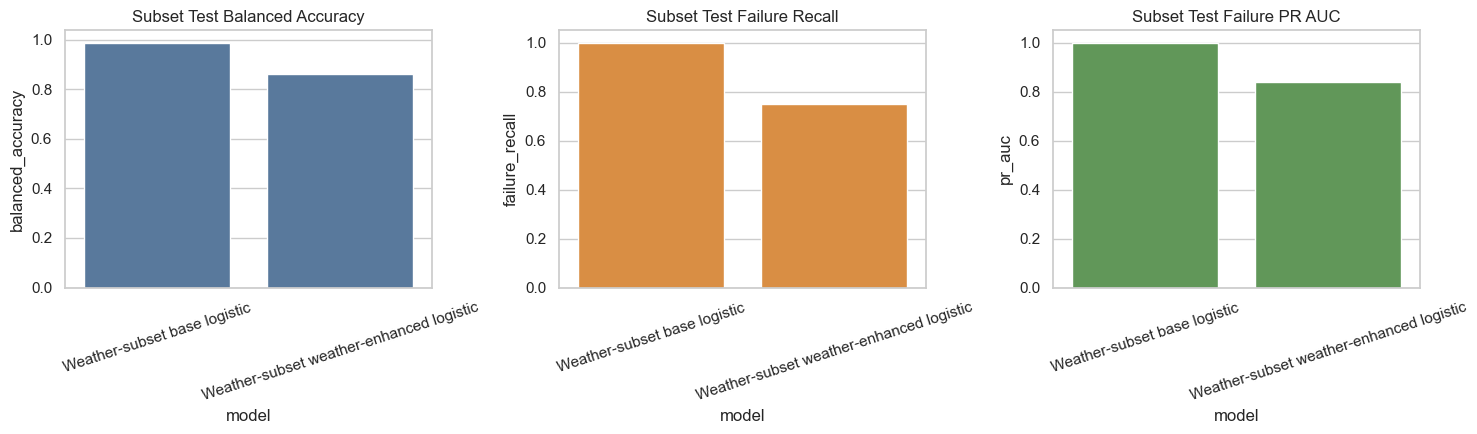

In [24]:
test_subset_benchmark = subset_benchmark[subset_benchmark["split"] == "test"].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.barplot(data=test_subset_benchmark, x="model", y="balanced_accuracy", ax=axes[0], color="#4e79a7")
axes[0].set_title("Subset Test Balanced Accuracy")
axes[0].tick_params(axis="x", rotation=18)

sns.barplot(data=test_subset_benchmark, x="model", y="failure_recall", ax=axes[1], color="#f28e2b")
axes[1].set_title("Subset Test Failure Recall")
axes[1].tick_params(axis="x", rotation=18)

sns.barplot(data=test_subset_benchmark, x="model", y="pr_auc", ax=axes[2], color="#59a14f")
axes[2].set_title("Subset Test Failure PR AUC")
axes[2].tick_params(axis="x", rotation=18)

plt.tight_layout()
plt.show()


#### How to read this chart

The chart asks whether adding weather variables changes the balance between recall, precision, and overall ranking quality inside the subset. In the current run, the base subset model is actually stronger on several thresholded test metrics, which suggests that restricting to cleaner rows may matter more than simply enlarging the weather feature block.


The key comparison in this notebook is not against the original full-sample model. It is whether weather variables help **within the subset where they are measured well enough to be trusted**.


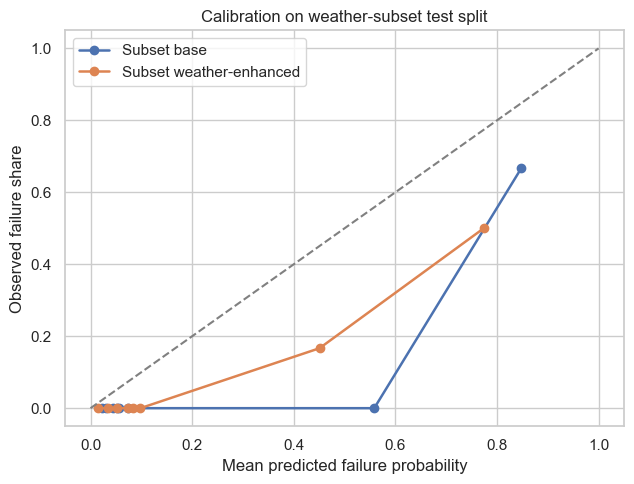

In [25]:
def plot_calibration_curves(prob_map, y_true, n_bins=8):
    plt.figure(figsize=(6.5, 5))
    for label, proba in prob_map.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", linewidth=1.8, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted failure probability")
    plt.ylabel("Observed failure share")
    plt.title("Calibration on weather-subset test split")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_calibration_curves(
    {
        "Subset base": subset_base_result["test_proba"],
        "Subset weather-enhanced": subset_weather_result["test_proba"],
    },
    sub_test["launch_failure_binary"],
)


#### What the calibration plot means here

Calibration is especially important in a small-sample subset experiment. Strong-looking classification metrics can happen by chance when only a few failures are present, so this plot acts as a qualitative check on whether the probability outputs still behave sensibly.


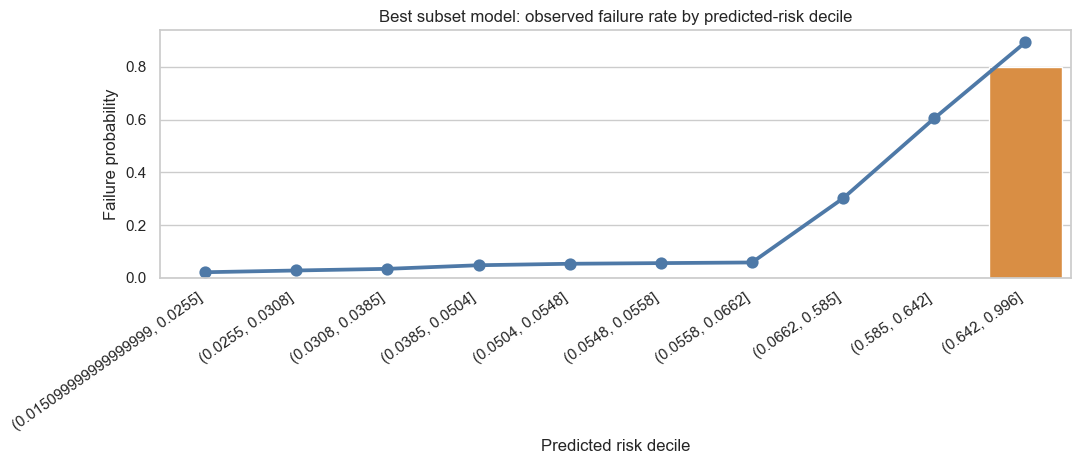

,risk_decile,launches,observed_failure_rate,mean_predicted_risk
0,"(0.015099999999999999, 0.0255]",5,0.0,0.021098
1,"(0.0255, 0.0308]",5,0.0,0.027698
2,"(0.0308, 0.0385]",5,0.0,0.033969
3,"(0.0385, 0.0504]",5,0.0,0.047618
4,"(0.0504, 0.0548]",5,0.0,0.053224
5,"(0.0548, 0.0558]",4,0.0,0.055724
6,"(0.0558, 0.0662]",5,0.0,0.058151
7,"(0.0662, 0.585]",6,0.0,0.301757
8,"(0.585, 0.642]",4,0.0,0.605064
9,"(0.642, 0.996]",5,0.8,0.893684


In [26]:
best_subset_output = (
    subset_base_result
    if subset_benchmark[subset_benchmark["split"] == "validation"].sort_values(
        ["balanced_accuracy", "pr_auc", "failure_f1"], ascending=False
    ).iloc[0]["model"] == "Weather-subset base logistic"
    else subset_weather_result
)

subset_test_df = sub_test.copy()
subset_test_df["predicted_failure_probability"] = best_subset_output["test_proba"]
subset_test_df["risk_decile"] = pd.qcut(
    subset_test_df["predicted_failure_probability"],
    q=10,
    duplicates="drop",
)

risk_bucket_summary = (
    subset_test_df.groupby("risk_decile", observed=False)
    .agg(
        launches=("Launch Id", "count"),
        observed_failure_rate=("launch_failure_binary", "mean"),
        mean_predicted_risk=("predicted_failure_probability", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(11, 4.8))
sns.barplot(data=risk_bucket_summary, x="risk_decile", y="observed_failure_rate", color="#f28e2b")
sns.pointplot(
    data=risk_bucket_summary,
    x="risk_decile",
    y="mean_predicted_risk",
    color="#4e79a7",
    linestyles="-",
    markers="o",
)
plt.title("Best subset model: observed failure rate by predicted-risk decile")
plt.xlabel("Predicted risk decile")
plt.ylabel("Failure probability")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

risk_bucket_summary


#### Why the risk-decile output matters

This is one of the most interpretable outputs in the notebook. It asks whether the best subset model is concentrating failures into the highest predicted-risk buckets. In your current run, the highest-risk decile contains most of the observed failures, which is promising.

At the same time, each decile contains only a few launches, so the result should be read as ?interesting evidence? rather than as a stable operational estimate.


The risk-decile output is especially useful here. Even if the weather-enhanced model does not dominate every threshold metric, it may still be better at concentrating failures into the highest-risk buckets, which is often the more practical use case.


In [27]:
full_vs_subset = pd.DataFrame(full_base_result["rows"] + subset_benchmark.to_dict("records")).sort_values(
    ["split", "balanced_accuracy", "pr_auc"],
    ascending=[True, False, False],
)
full_vs_subset


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
2,Weather-subset base logistic,test,0.645,0.979592,0.988889,0.800000,1.000000,0.888889,1.000000,1.000000,0.061034
3,Weather-subset weather-enhanced logistic,test,0.595,0.959184,0.863889,0.750000,0.750000,0.750000,0.961111,0.840909,0.049863
1,Full-sample base logistic,test,0.095,0.955182,0.717688,0.400000,0.461538,0.428571,0.865385,0.385021,0.029737
4,Weather-subset base logistic,validation,0.645,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.026841
5,Weather-subset weather-enhanced logistic,validation,0.595,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.022002
0,Full-sample base logistic,validation,0.095,0.764706,0.763393,0.168421,0.761905,0.275862,0.782100,0.329937,0.051364


#### How to interpret the full-vs-subset table

This is not a strict apples-to-apples leaderboard because the subset models are evaluated on a different population from the full-sample base model. The right interpretation is:

- the full-sample base model is the robust general benchmark
- the subset models test whether a cleaner weather slice supports stronger local performance
- the subset results are promising but not yet strong enough to displace the full-sample approach


In [28]:
full_vs_subset.to_csv(DATA_DIR / "model_weather_subset_benchmark_results_v2.csv", index=False)
print("Saved benchmark results to", DATA_DIR / "model_weather_subset_benchmark_results_v2.csv")


Saved benchmark results to data\derived\model_weather_subset_benchmark_results_v2.csv


#### Overall interpretation

This notebook does not yet prove that a weather-subset workflow is superior, but it does show that the idea is worth exploring. The main lesson is procedural: weather may be more useful when treated as a high-quality subset problem rather than a universal feature block. The next step would be to strengthen the subset definition and validation design before drawing firm conclusions.
